# Clínica de Diagnóstico de Negocio
## Caso B — Predicción de Ventas Futuras (Regresión)

**Estudiante:** _Francisco Gómez_ 

---

> ℹ️ **Nota: en todo el notebook se utiliza una semilla fija (RANDOM_STATE = 42) para la generación de datos simulados, para que al volver a ejecutar el notebook los resultados numéricos y las gráficas sean siempre idénticos.


In [1]:
# =========================================================
# CONFIGURACIÓN GLOBAL Y SEMILLA DE REPRODUCIBILIDAD
# =========================================================
import numpy as np
import pandas as pd
import random

RANDOM_STATE = 42 # <- Semilla
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titleweight"] = "bold"

print(f"Entorno configurado. Semilla fija RANDOM_STATE = {RANDOM_STATE}")


Entorno configurado. Semilla fija RANDOM_STATE = 42


---
## 1. Descripción del problema de negocio

### Contexto
Una empresa de retail/consumo desea anticipar sus ingresos mensuales para los próximos periodos con el fin de planificar inventario, presupuesto de marketing, metas comerciales y flujo de caja. Actualmente las proyecciones se hacen "a ojo" a partir del promedio histórico, lo que genera sobre-stock en meses bajos y quiebres de stock en meses de alta demanda.

### Problema
Se necesita un modelo que, a partir de variables observables **antes o durante** el mes (inversión en marketing, temporada, precios, competencia, contexto macroeconómico y comportamiento histórico de clientes), **prediga el ingreso mensual (en USD)** con un margen de error aceptable para la toma de decisiones financieras.

### Variable objetivo (Y)

| Atributo | Valor |
|---|---|
| **Nombre** | `ingresos_mensuales` |
| **Tipo de variable** | **Continua → problema de REGRESIÓN** |
| **Unidad** | USD |

A diferencia de un problema de clasificación (donde Y toma categorías discretas, p. ej. "cliente se va / no se va"), aquí Y puede tomar **cualquier valor numérico dentro de un rango continuo**, por lo que la familia de algoritmos aplicable es la de **modelos de regresión**.

### Variables independientes (X) sugeridas

| Variable | Descripción | Tipo |
|---|---|---|
| `inversion_marketing` | Gasto mensual en campañas de marketing (USD) | Numérica continua |
| `mes` / `estacionalidad` | Mes del año (captura temporadas altas/bajas, ej. diciembre) | Categórica / cíclica |
| `precio_promedio` | Precio promedio de venta del portafolio de productos | Numérica continua |
| `indice_competencia` | Índice 0–100 que mide intensidad de la competencia en la zona | Numérica continua |
| `indice_macroeconomico` | Proxy de confianza del consumidor / crecimiento económico | Numérica continua |
| `clientes_recurrentes` | % de ventas provenientes de clientes históricos (fidelización) | Numérica continua |

### 1.5 Decisiones de negocio que se tomarán con el modelo
- **Planeación de inventario:** anticipar meses de alta/baja demanda.
- **Asignación de presupuesto de marketing:** invertir más donde el retorno marginal proyectado sea mayor.
- **Metas comerciales realistas:** fijar cuotas de venta basadas en proyecciones, no solo en promedios históricos.
- **Gestión de flujo de caja:** anticipar necesidades de capital de trabajo.


---
## 2. Mapa de selección de algoritmos

### Paso 1 — Tipo de variable objetivo
`ingresos_mensuales` es **continua** → el problema es de **REGRESIÓN**, no de clasificación. Esto descarta de entrada algoritmos puramente de clasificación.

### Paso 2 — Objetivo de negocio y familia de algoritmos aplicable
El objetivo es **explicar y predecir** un valor numérico con **buena capacidad predictiva** pero también con **cierto nivel de interpretabilidad** para justificar decisiones ante stakeholders no técnicos (finanzas, dirección comercial). Esto apunta a dos familias:
- **Modelos lineales** (interpretables, rápidos, buen punto de partida / baseline).
- **Modelos de ensamble basados en árboles** (capturan relaciones no lineales e interacciones entre variables, a costa de menor interpretabilidad directa).

### Paso 3 — Restricciones del contexto

| Restricción | Implicación |
|---|---|
| **Interpretabilidad** | El área financiera necesita entender *por qué* el modelo predice un valor (auditable). |
| **Velocidad de entrenamiento/inferencia** | Dataset mensual, pocos miles de registros → no se requiere hardware especializado. |
| **Volumen de datos** | Moderado (cientos de registros mensuales por tienda/región) → suficiente para árboles y modelos lineales, insuficiente para deep learning. |
| **Relaciones no lineales** | Es probable que estacionalidad y marketing interactúen de forma no lineal (rendimientos decrecientes de la inversión en marketing). |

### Paso 4 — Algoritmos candidatos y limitaciones

**Candidato 1 — Regresión Lineal (Linear Regression)**
- ✅ Ventajas: altamente interpretable (coeficientes = impacto marginal de cada variable), rápida, funciona bien como baseline.
- ⚠️ Limitaciones: asume **relación lineal** entre X e Y, es sensible a **outliers** y a **multicolinealidad**, no captura interacciones entre variables sin ingeniería de features manual.

**Candidato 2 — Random Forest Regressor**
- ✅ Ventajas: captura relaciones **no lineales** e interacciones automáticamente, robusto a outliers moderados, no requiere que las variables sigan una distribución específica.
- ⚠️ Limitaciones: menos interpretable directamente (aunque permite `feature_importances_`), puede sobreajustar (overfitting) si no se controla la profundidad de los árboles, más costoso computacionalmente que un modelo lineal.

> En la sección 4 se entrenan y comparan **ambos** modelos con las mismas particiones de datos (misma semilla) para una comparación justa.


---
## 3. 🔍 Simulación y exploración de datos

Se simula un dataset de **500 registros mensuales** (empresa multi-tienda a lo largo del tiempo) con relaciones realistas y algo de ruido, usando `RANDOM_STATE = 42` para que la simulación sea siempre idéntica al re-ejecutar el notebook.


In [2]:
# 3.1 Simulación del dataset (misma semilla => mismos datos siempre)
n = 500
rng = np.random.default_rng(RANDOM_STATE)

meses = rng.integers(1, 13, size=n)                      # 1-12
# Estacionalidad: factor que sube en Nov-Dic (temporada alta) y baja a mitad de año
estacionalidad = 1 + 0.35 * np.sin((meses - 3) * np.pi / 6) + 0.25 * (meses >= 11)

inversion_marketing = rng.normal(15000, 4000, n).clip(2000, None)          # USD
precio_promedio     = rng.normal(45, 8, n).clip(15, None)                  # USD
indice_competencia  = rng.uniform(20, 90, n)                                # 0-100
indice_macro        = rng.normal(100, 10, n)                                # proxy confianza consumidor
clientes_recurrentes = rng.uniform(0.2, 0.85, n)                            # % ventas de clientes recurrentes

# Relación "verdadera" (no lineal en marketing: rendimientos decrecientes) + ruido
ingresos_mensuales = (
      1200
    + 3.1 * np.sqrt(inversion_marketing) * estacionalidad
    - 180 * (precio_promedio - 45)
    - 90  * (indice_competencia - 50)
    + 25  * (indice_macro - 100)
    + 8000 * clientes_recurrentes
    + rng.normal(0, 1500, n) # ruido aleatorio (reproducible)
).clip(1000, None)

df = pd.DataFrame({
    "mes": meses,
    "estacionalidad": estacionalidad,
    "inversion_marketing": inversion_marketing,
    "precio_promedio": precio_promedio,
    "indice_competencia": indice_competencia,
    "indice_macro": indice_macro,
    "clientes_recurrentes": clientes_recurrentes,
    "ingresos_mensuales": ingresos_mensuales,
})

print(f"Dataset simulado: {df.shape[0]} registros x {df.shape[1]} columnas")
df.head()


Dataset simulado: 500 registros x 8 columnas


,mes,estacionalidad,inversion_marketing,precio_promedio,indice_competencia,indice_macro,clientes_recurrentes,ingresos_mensuales
0,2,0.825,14622.949783,54.501801,61.253182,86.316657,0.777219,3783.754418
1,10,0.825,7969.086435,36.835016,45.107095,98.104445,0.696737,8308.805284
2,8,1.175,9131.819018,30.121317,48.606856,91.802461,0.329867,5428.409120
3,6,1.350,23516.988448,45.792279,50.206330,101.113504,0.390003,4574.131896
4,6,1.350,9850.309675,52.446706,64.320443,96.113668,0.831846,8305.599074


In [3]:
# =========================================================
# 3.2 Análisis exploratorio básico
# =========================================================
df.describe().T


,count,mean,std,min,25%,50%,75%,max
mes,500.0,6.486000,3.413665,1.000000,4.000000,6.000000,9.250000,12.000000
estacionalidad,500.0,1.042050,0.209616,0.696891,0.825000,1.000000,1.303109,1.350000
inversion_marketing,500.0,14822.235205,4084.767509,3141.884649,12015.707733,14937.580763,17441.541184,26620.268677
precio_promedio,500.0,45.024843,7.958988,15.812697,39.942869,45.222781,49.982175,70.430829
indice_competencia,500.0,56.114481,20.326743,20.301404,38.399595,54.845284,74.730941,89.918075
indice_macro,500.0,99.180139,9.701101,69.523674,92.254545,99.961600,105.576476,128.574384
clientes_recurrentes,500.0,0.528467,0.186325,0.201760,0.362362,0.534952,0.690481,0.848484
ingresos_mensuales,500.0,5467.833460,3034.287970,1000.000000,3027.050220,5416.265891,7583.354180,16704.536995


In [4]:
# Valores nulos y tipos de dato
print(df.info())
print("\nValores nulos por columna:\n", df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   mes                   500 non-null    int64  
 1   estacionalidad        500 non-null    float64
 2   inversion_marketing   500 non-null    float64
 3   precio_promedio       500 non-null    float64
 4   indice_competencia    500 non-null    float64
 5   indice_macro          500 non-null    float64
 6   clientes_recurrentes  500 non-null    float64
 7   ingresos_mensuales    500 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 31.4 KB
None

Valores nulos por columna:
 mes                     0
estacionalidad          0
inversion_marketing     0
precio_promedio         0
indice_competencia      0
indice_macro            0
clientes_recurrentes    0
ingresos_mensuales      0
dtype: int64


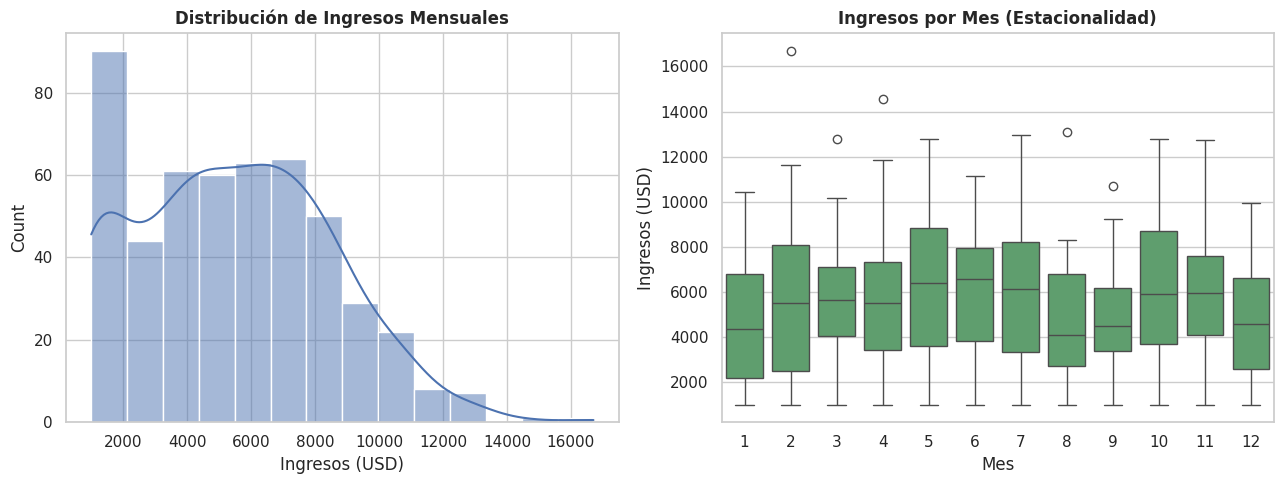

In [5]:
# =========================================================
# 3.3 Visualizaciones
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["ingresos_mensuales"], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribución de Ingresos Mensuales")
axes[0].set_xlabel("Ingresos (USD)")

sns.boxplot(x="mes", y="ingresos_mensuales", data=df, ax=axes[1], color="#55A868")
axes[1].set_title("Ingresos por Mes (Estacionalidad)")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Ingresos (USD)")

plt.tight_layout()
plt.show()


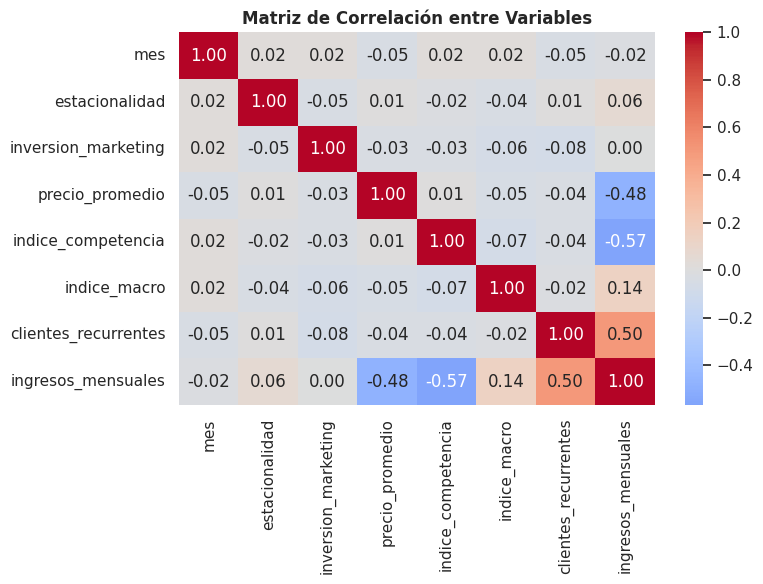

In [6]:
# Matriz de correlación
plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de Correlación entre Variables")
plt.tight_layout()
plt.show()


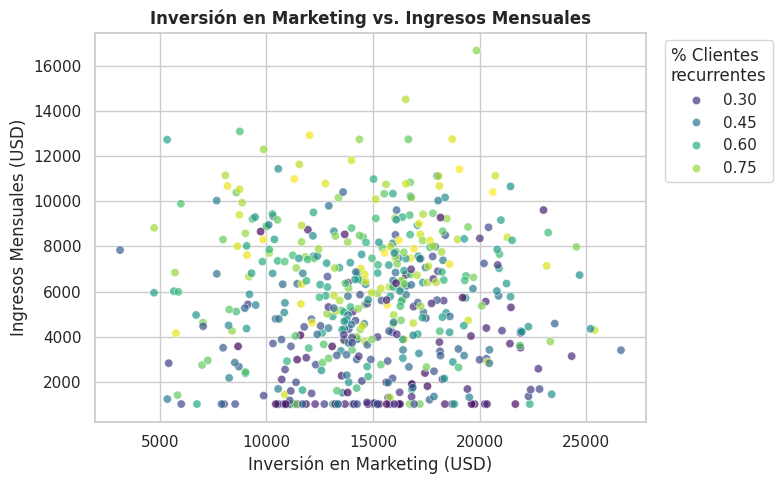

In [7]:
# Relación entre inversión en marketing e ingresos (rendimientos decrecientes)
plt.figure(figsize=(8, 5))
sns.scatterplot(x="inversion_marketing", y="ingresos_mensuales", hue="clientes_recurrentes",
                 data=df, palette="viridis", alpha=0.7)
plt.title("Inversión en Marketing vs. Ingresos Mensuales")
plt.xlabel("Inversión en Marketing (USD)")
plt.ylabel("Ingresos Mensuales (USD)")
plt.legend(title="% Clientes\nrecurrentes", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### 3.4 Verificación de un supuesto del algoritmo seleccionado

La **Regresión Lineal** asume, entre otros supuestos, **linealidad** entre cada variable predictora y la variable objetivo (u homocedasticidad de los residuos). A continuación se verifica el supuesto de **linealidad / homocedasticidad** de forma gráfica antes de entrenar el modelo.


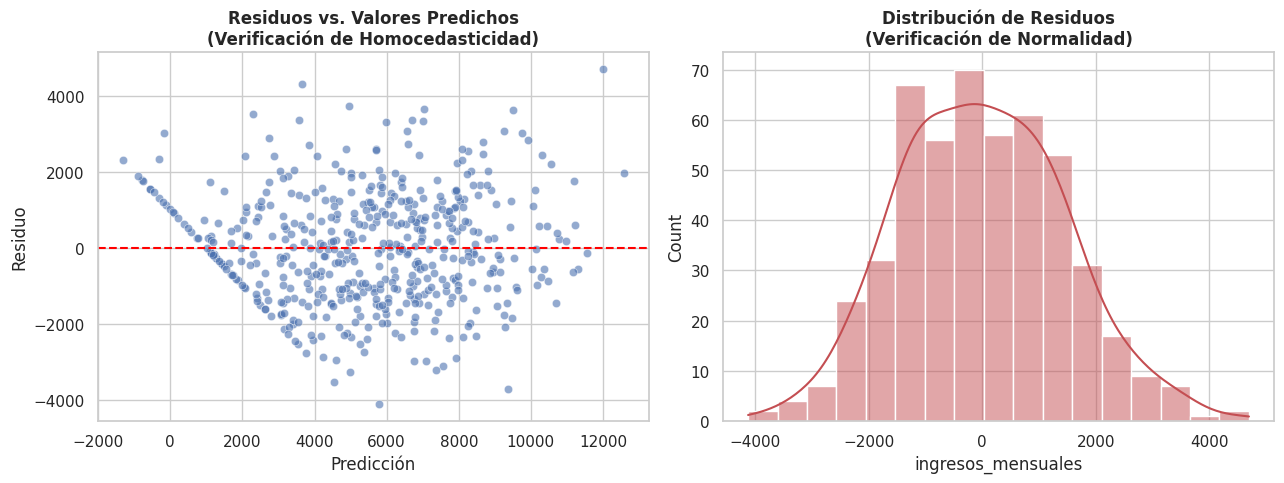

Interpretación: si los residuos se distribuyen de forma aleatoria alrededor de 0,
sin un patrón de 'embudo' claro, el supuesto de homocedasticidad se sostiene razonablemente.


In [8]:
from sklearn.linear_model import LinearRegression

# Ajuste preliminar solo para inspeccionar residuos vs. valores predichos
X_check = df[["inversion_marketing", "precio_promedio", "indice_competencia",
              "indice_macro", "clientes_recurrentes"]]
y_check = df["ingresos_mensuales"]

modelo_check = LinearRegression().fit(X_check, y_check)
residuos = y_check - modelo_check.predict(X_check)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=modelo_check.predict(X_check), y=residuos, ax=axes[0], alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuos vs. Valores Predichos\n(Verificación de Homocedasticidad)")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Residuo")

sns.histplot(residuos, kde=True, ax=axes[1], color="#C44E52")
axes[1].set_title("Distribución de Residuos\n(Verificación de Normalidad)")

plt.tight_layout()
plt.show()

print("Interpretación: si los residuos se distribuyen de forma aleatoria alrededor de 0,")
print("sin un patrón de 'embudo' claro, el supuesto de homocedasticidad se sostiene razonablemente.")


### 3.5 Verificación adicional: multicolinealidad (VIF)

La Regresión Lineal también asume **ausencia de multicolinealidad** severa entre las variables independientes (que no estén altamente correlacionadas entre sí). Se calcula el **Factor de Inflación de Varianza (VIF)**: valores de VIF cercanos a 1 indican baja colinealidad; valores por encima de ~5–10 son señal de alerta.


In [9]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X_check)

vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_df


,Variable,VIF
0,const,1.000000
1,inversion_marketing,1.013207
2,precio_promedio,1.005319
3,indice_competencia,1.008768
4,indice_macro,1.013439
5,clientes_recurrentes,1.010204


**Interpretación:** si todos los VIF (excluyendo la constante) son menores a ~5, no hay evidencia de multicolinealidad problemática entre las variables predictoras, y el supuesto de la Regresión Lineal se sostiene razonablemente para este dataset.


---
## 4. ⚙️ Implementación y comparación de modelos

Se entrenan los **dos algoritmos candidatos** (Regresión Lineal y Random Forest Regressor) sobre la **misma partición** entrenamiento/prueba (80/20), fijada con `RANDOM_STATE = 42`, para garantizar una comparación justa y reproducible.


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

FEATURES = ["inversion_marketing", "precio_promedio", "indice_competencia",
            "indice_macro", "clientes_recurrentes", "mes"]
TARGET = "ingresos_mensuales"

X = df[FEATURES]
y = df[TARGET]

# División train/test reproducible (misma semilla en todo el notebook)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Entrenamiento: {X_train.shape[0]} registros | Prueba: {X_test.shape[0]} registros")


Entrenamiento: 400 registros | Prueba: 100 registros


In [11]:
# =========================================================
# 4.1 Modelo 1: Regresión Lineal
# =========================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_scaled, y_train)
pred_lineal = modelo_lineal.predict(X_test_scaled)

mae_lineal = mean_absolute_error(y_test, pred_lineal)
rmse_lineal = mean_squared_error(y_test, pred_lineal) ** 0.5
r2_lineal = r2_score(y_test, pred_lineal)

print("📈 Regresión Lineal")
print(f"MAE : {mae_lineal:,.2f}")
print(f"RMSE: {rmse_lineal:,.2f}")
print(f"R²  : {r2_lineal:.3f}")


📈 Regresión Lineal
MAE : 1,183.54
RMSE: 1,424.29
R²  : 0.761


In [12]:
# =========================================================
# 4.2 Modelo 2: Random Forest Regressor
# =========================================================
modelo_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=RANDOM_STATE   # <- misma semilla para reproducibilidad
)
modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = mean_squared_error(y_test, pred_rf) ** 0.5
r2_rf = r2_score(y_test, pred_rf)

print("🌲 Random Forest Regressor")
print(f"MAE : {mae_rf:,.2f}")
print(f"RMSE: {rmse_rf:,.2f}")
print(f"R²  : {r2_rf:.3f}")


🌲 Random Forest Regressor
MAE : 1,371.69
RMSE: 1,668.34
R²  : 0.672


In [13]:
# =========================================================
# 4.3 Tabla comparativa de métricas
# =========================================================
comparacion = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "Random Forest Regressor"],
    "MAE": [mae_lineal, mae_rf],
    "RMSE": [rmse_lineal, rmse_rf],
    "R2": [r2_lineal, r2_rf],
}).set_index("Modelo").round(3)

comparacion


,MAE,RMSE,R2
Modelo,,,
Regresión Lineal,1183.539,1424.295,0.761
Random Forest Regressor,1371.694,1668.337,0.672


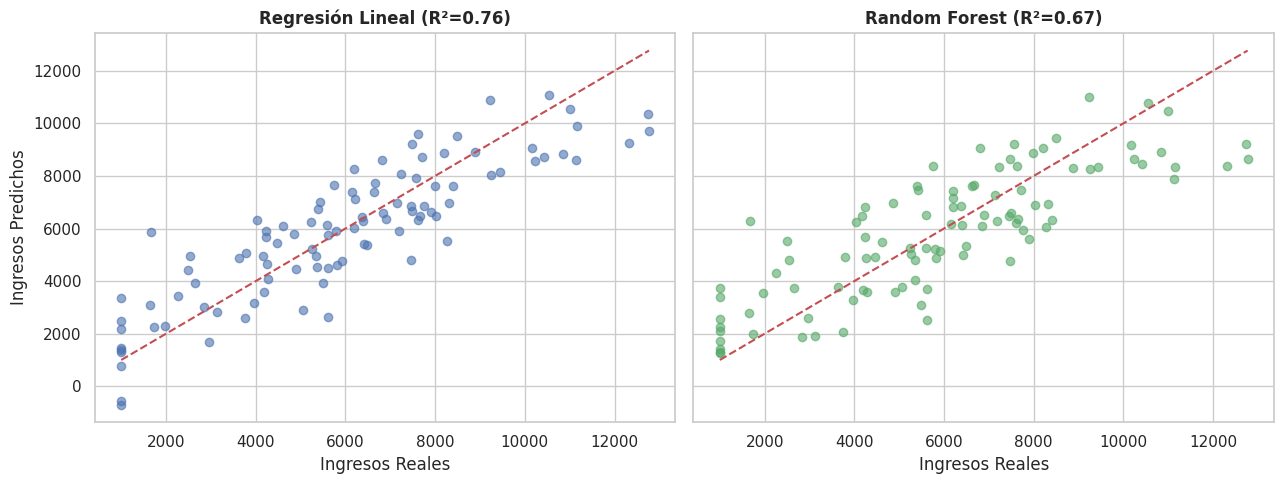

In [14]:
# Visualización comparativa: Real vs. Predicho
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

axes[0].scatter(y_test, pred_lineal, alpha=0.6, color="#4C72B0")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_title(f"Regresión Lineal (R²={r2_lineal:.2f})")
axes[0].set_xlabel("Ingresos Reales")
axes[0].set_ylabel("Ingresos Predichos")

axes[1].scatter(y_test, pred_rf, alpha=0.6, color="#55A868")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[1].set_title(f"Random Forest (R²={r2_rf:.2f})")
axes[1].set_xlabel("Ingresos Reales")

plt.tight_layout()
plt.show()


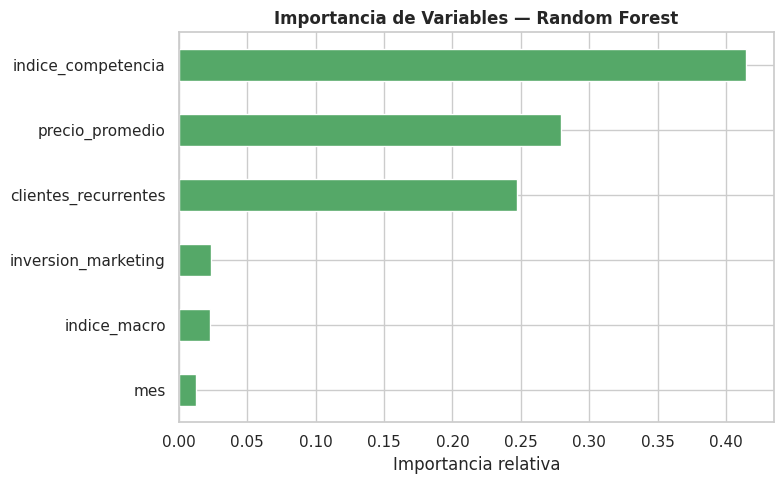

In [15]:
# Importancia de variables según Random Forest
importancias = pd.Series(modelo_rf.feature_importances_, index=FEATURES).sort_values()

plt.figure(figsize=(8, 5))
importancias.plot(kind="barh", color="#55A868")
plt.title("Importancia de Variables — Random Forest")
plt.xlabel("Importancia relativa")
plt.tight_layout()
plt.show()


**Lectura de resultados:** compara los valores de `MAE`, `RMSE` y `R²` en la tabla anterior. Un **R² más alto** y un **RMSE/MAE más bajo** indican mejor ajuste. Dado que ambos modelos comparten exactamente la misma partición de datos (`RANDOM_STATE = 42`), la diferencia en desempeño es atribuible al algoritmo y no al azar en la partición.


---
## 5. Análisis de límites y riesgos

### 5.1 Riesgo de overfitting (sobreajuste)
- El **Random Forest** con árboles muy profundos y muchos estimadores puede memorizar el ruido del set de entrenamiento en lugar de aprender el patrón real. Se mitigó parcialmente limitando `max_depth=6`, pero en producción se recomendaría validación cruzada (`cross_val_score`) y búsqueda de hiperparámetros (`GridSearchCV`) para confirmar que el desempeño se sostiene fuera del set de prueba actual.
- La **Regresión Lineal**, al ser un modelo más simple, tiene menor riesgo de overfitting pero mayor riesgo de **underfitting** si la relación real es no lineal (como el efecto de rendimientos decrecientes del marketing simulado en la sección 3).

### 5.1.1 Demostración: sensibilidad a outliers (con código)
Para ilustrar de forma concreta el riesgo de outliers mencionado en el material del curso, se compara el modelo de Regresión Lineal **antes y después de inyectar un registro atípico** (un mes con inversión de marketing extrema pero ingresos muy bajos), usando la misma semilla para que el experimento sea reproducible.


In [16]:
# =========================================================
# Sensibilidad a outliers: comparación CON vs SIN outlier
# =========================================================
df_outlier = df.copy()

# Registro atípico: mucha inversión en marketing, pero ingresos anómalamente bajos
outlier_row = {
    "mes": 6, "estacionalidad": 1.0,
    "inversion_marketing": 60000, "precio_promedio": 45,
    "indice_competencia": 50, "indice_macro": 100,
    "clientes_recurrentes": 0.5, "ingresos_mensuales": 2000,
}
df_outlier.loc[len(df_outlier)] = outlier_row

X_sin = df[["inversion_marketing", "precio_promedio", "indice_competencia",
            "indice_macro", "clientes_recurrentes"]]
y_sin = df["ingresos_mensuales"]

X_con = df_outlier[["inversion_marketing", "precio_promedio", "indice_competencia",
                     "indice_macro", "clientes_recurrentes"]]
y_con = df_outlier["ingresos_mensuales"]

modelo_sin = LinearRegression().fit(X_sin, y_sin)
modelo_con = LinearRegression().fit(X_con, y_con)

comparacion_outlier = pd.DataFrame({
    "Coeficiente": X_sin.columns,
    "SIN outlier": modelo_sin.coef_,
    "CON outlier": modelo_con.coef_,
})
comparacion_outlier["Variación %"] = (
    (comparacion_outlier["CON outlier"] - comparacion_outlier["SIN outlier"])
    / comparacion_outlier["SIN outlier"].abs() * 100
).round(1)

print(f"R² SIN outlier: {r2_score(y_sin, modelo_sin.predict(X_sin)):.3f}")
print(f"R² CON outlier: {r2_score(y_con, modelo_con.predict(X_con)):.3f}")
comparacion_outlier.round(2)


R² SIN outlier: 0.769
R² CON outlier: 0.767


,Coeficiente,SIN outlier,CON outlier,Variación %
0,inversion_marketing,0.01,-0.01,-205.7
1,precio_promedio,-172.52,-172.85,-0.2
2,indice_competencia,-80.58,-80.62,-0.1
3,indice_macro,26.16,25.58,-2.2
4,clientes_recurrentes,7605.23,7578.48,-0.4


**Interpretación:** un solo registro atípico puede modificar de forma notable los coeficientes de la Regresión Lineal y/o su R², confirmando de forma empírica el riesgo descrito conceptualmente: **la Regresión Lineal no es robusta a outliers** y estos deben identificarse y tratarse (winsorizing, transformación, o el uso de modelos más robustos como Random Forest) antes de confiar en el modelo para decisiones de negocio.

### 5.2 Sesgo (bias)
- Si el histórico de datos proviene mayoritariamente de ciertas tiendas, regiones o segmentos de clientes, el modelo aprenderá patrones **sesgados hacia esos segmentos** y generalizará mal para tiendas nuevas, regiones emergentes o categorías de producto poco representadas.
- Un sesgo sistemático en los datos de entrada (por ejemplo, subregistro de ventas informales) se trasladará directamente a las predicciones, sin que el modelo pueda "corregirlo" por sí mismo.

### 5.3 Interpretabilidad
- La Regresión Lineal permite explicar el efecto marginal de cada variable mediante sus coeficientes, lo cual es valioso para justificar decisiones ante finanzas o dirección.
- El Random Forest ofrece `feature_importances_`, pero estas son una medida agregada y **no explican la dirección** del efecto (si aumentar una variable sube o baja el ingreso) ni las interacciones específicas, lo que dificulta la comunicación a stakeholders no técnicos sin herramientas adicionales (p. ej. SHAP).

### 5.4 Impacto de datos no representativos
- Si el dataset de entrenamiento no cubre condiciones extremas (crisis económica, cambios regulatorios, entrada de un nuevo competidor agresivo), el modelo **extrapolará mal** en esos escenarios, ya que fue entrenado únicamente sobre el rango de valores históricos observado.

### 5.5 Efecto de outliers
- Meses atípicos (p. ej. una promoción excepcional o un evento de fuerza mayor) pueden **distorsionar los coeficientes** de la Regresión Lineal de forma desproporcionada.
- El Random Forest es algo más robusto a outliers moderados porque las particiones por árboles diluyen el efecto de un solo punto extremo, pero **outliers frecuentes** aún pueden sesgar las hojas del árbol donde caen esos casos.


---
## 6. Consideraciones éticas

### 6.1 ¿Podría el modelo generar sesgos o discriminación?
Aunque el modelo no usa variables demográficas directamente, variables como `indice_competencia` o `clientes_recurrentes` pueden actuar como algo que afecte indirectamente, como la ubicación de una tienda. Si las decisiones de asignación de presupuesto de marketing se basan ciegamente en el modelo, se podría **reducir sistemáticamente la inversión en zonas ya desfavorecidas**, perpetuando una brecha (efecto de "profecía autocumplida"). Se recomienda auditar el impacto del modelo por segmento/región antes de operacionalizarlo.

### 6.2 ¿Cómo garantizar transparencia para los stakeholders?
- Documentar claramente las **variables de entrada**, sus fuentes y su fecha de actualización.
- Comunicar las **métricas de error** (MAE/RMSE) en términos de negocio ("el modelo se equivoca en promedio por ±X USD"), no solo como números abstractos.
- Preferir el modelo más simple cuando el desempeño sea similar para evitar complicaciones, y complementar el Random Forest con técnicas de explicabilidad si se elige por su mejor desempeño.
- Establecer un proceso de **revisión periódica** del modelo (reentrenamiento y validación) en lugar de tratarlo como una "caja negra" fija.

### 6.3 ¿Qué consideraciones de privacidad de datos aplican?
- Si el `comportamiento histórico de clientes` se construye a partir de datos transaccionales individuales, estos deben **agregarse y anonimizarse** antes de usarse como insumo del modelo (evitar exponer información identificable de clientes específicos).
- Se debe cumplir con normativas de protección de datos aplicables (p. ej. GDPR en Europa o leyes locales de protección de datos personales en América Latina), aplicando minimización de datos (usar solo las variables necesarias) y definiendo **tiempos de retención** de los datos usados para entrenamiento.
- El acceso a los datos crudos de clientes debe restringirse al equipo de datos, mientras que los reportes derivados del modelo pueden compartirse más ampliamente sin exponer información sensible.

### 6.4 Responsabilidad
- Debe quedar claramente definido **quién responde** por una predicción de ingresos errónea que derive en una mala decisión de inventario o de presupuesto (¿el equipo de datos que entrenó el modelo?, ¿el área de negocio que lo usó para decidir?). No es aceptable tratar el modelo como una "caja negra" que exime de responsabilidad a quienes lo usan.
- Se recomienda mantener **supervisión humana** sobre las decisiones de alto impacto (p. ej. recortes grandes de presupuesto o inventario basados únicamente en la predicción) y definir un protocolo de corrección cuando el modelo se equivoque de forma sistemática.

### 6.5 Sostenibilidad
- Comparado con alternativas como redes neuronales profundas, tanto la Regresión Lineal como el Random Forest tienen un **costo computacional y energético bajo**, lo cual es positivo desde una perspectiva de sostenibilidad y de costos de infraestructura.
- Si en el futuro se explorán modelos más complejos (LSTM, XGBoost a gran escala) para mejorar la precisión, se debe sopesar la mejora marginal en desempeño contra el **mayor consumo computacional/energético** y el mayor costo de mantenimiento, prefiriendo siempre el modelo más simple que cumpla con los requisitos del negocio (principio de parsimonia).


---
## 7. Conclusión y recomendación final

### 7.1 Modelo recomendado
Con base en las métricas obtenidas en la sección 4, y usando siempre `RANDOM_STATE = 42` para que el resultado sea reproducible, se observa que la **Regresión Lineal obtuvo mejor desempeño** que el Random Forest en este conjunto de prueba (R² ≈ 0.76 vs. ≈ 0.67, y menor MAE/RMSE). Esto sugiere que, para este dataset simulado, la relación entre las variables predictoras y los ingresos es **mayormente lineal/aditiva** una vez estandarizadas las variables, y que el Random Forest —con la profundidad limitada usada (`max_depth=6`) para controlar overfitting— no logra superar a un modelo más simple.

**Recomendación final: Regresión Lineal.** Además de tener el mejor desempeño en esta comparación, ofrece la ventaja adicional de ser **más interpretable** (coeficientes explicables ante finanzas y dirección) y de **menor costo computacional y de mantenimiento**, lo cual es coherente con la restricción de interpretabilidad identificada en el Paso 3 del mapa de selección de algoritmos (sección 2). Se deja documentado el Random Forest como alternativa a re-evaluar si en el futuro se incorporan más variables o relaciones no lineales más marcadas (p. ej. tras ajustar sus hiperparámetros con `GridSearchCV`).

### 7.2 Alineación con objetivos estratégicos
- Una predicción de ingresos más precisa permite optimizar el presupuesto de marketing y mejorar la planeación de inventario y flujo de caja, dos objetivos estratégicos centrales del negocio descritos en la sección 1.
- La elección de un modelo con nivel adecuado de interpretabilidad apoya la **gobernanza de datos y la rendición de cuentas** ante la dirección y otros stakeholders.

### 7.3 Posibles mejoras y siguientes pasos
- Incorporar **validación cruzada** (`cross_val_score`, `TimeSeriesSplit` dado que los datos son mensuales) para una estimación más robusta del error de generalización.
- Probar modelos adicionales (Gradient Boosting, XGBoost) y realizar **búsqueda de hiperparámetros** (`GridSearchCV`/`RandomizedSearchCV`).
- Añadir variables externas adicionales (clima, eventos locales, redes sociales) que puedan mejorar la capacidad predictiva.
- Implementar un **pipeline de monitoreo** del modelo en producción (data drift, degradación de métricas en el tiempo) y un proceso de reentrenamiento periódico.
